### Notebook 05: Interpretabilidad del modelo

### SHAP y LIME sobre la Regresión Logística

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shap
import lime
import lime.lime_tabular

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# --- Rutas ancladas ---
RUTA_BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
RUTA_SHAP = os.path.join(RUTA_BASE, 'reports', 'shap')
os.makedirs(RUTA_SHAP, exist_ok=True)

In [2]:
# --- Carga del dataset limpio ---
df = pd.read_csv(os.path.join(RUTA_BASE, 'data', 'processed', 'ibm_hr_clean.csv'))

# --- One-hot encoding --- 
ibm_encoded = pd.get_dummies(df, drop_first=True)
X = ibm_encoded.drop(columns=['Attrition'])
y = ibm_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# --- Reentrenamiento del modelo ganador ---
modelo_lr = Pipeline([
    ('escalado', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced',
                              max_iter=200, random_state=42))
])
modelo_lr.fit(X_train, y_train)

# --- Verificacion de consistencia ---
print("Test:", X_test.shape[0], "filas |", X.shape[1], "columnas")

Test: 441 filas | 44 columnas


## SHAP

In [3]:
# --- Extracción de scaler y modelo del pipeline ---
scaler = modelo_lr.named_steps['escalado']
lr_modelo = modelo_lr.named_steps['lr']

X_test_escalado = scaler.transform(X_test)
X_test_escalado = pd.DataFrame(X_test_escalado, columns=X_test.columns,
                               index=X_test.index)

# --- SHAP ---
masker = shap.maskers.Independent(X_test_escalado, max_samples=441)
explainer = shap.LinearExplainer(lr_modelo, masker)
shap_values = explainer(X_test_escalado)   

print("Valores SHAP calculados:", shap_values.shape) 

Valores SHAP calculados: (441, 44)


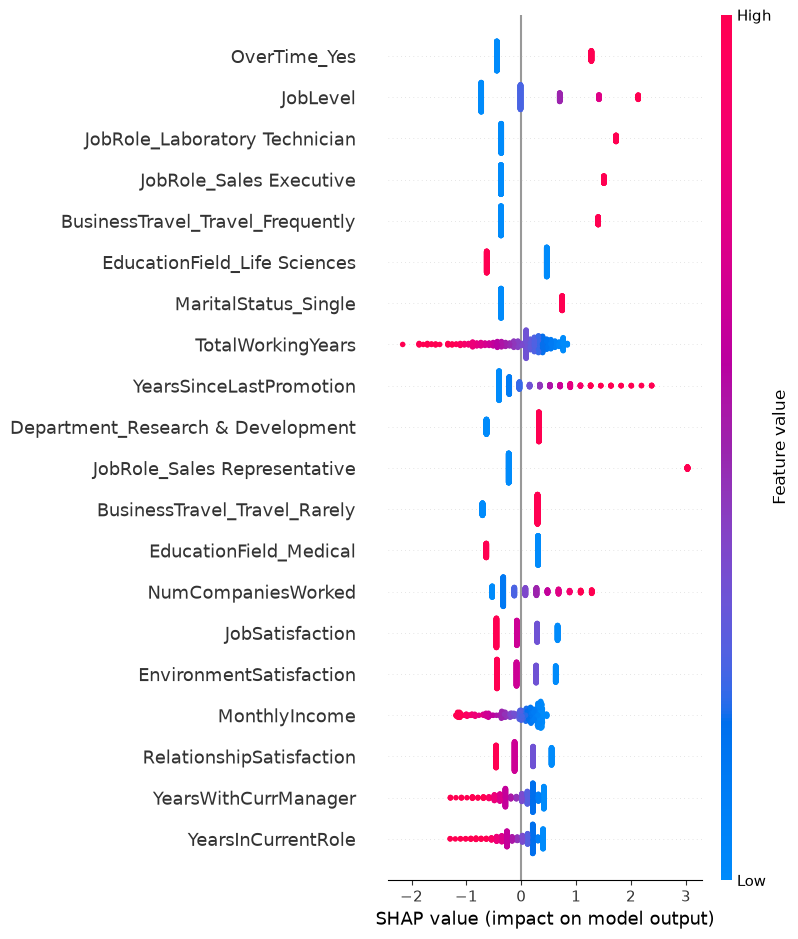

In [4]:
# --- Importancia de cada variable ---
shap.summary_plot(shap_values, X_test_escalado, show=False)
plt.savefig(os.path.join(RUTA_SHAP, 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Coeficientes del LR para validar semejanza con el Summary Plot
coeficientes = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': lr_modelo.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

print(coeficientes.head(15))

                             variable  coeficiente
34      JobRole_Laboratory Technician     0.798219
39            JobRole_Sales Executive     0.791995
43                       OverTime_Yes     0.784311
7                            JobLevel     0.775677
40       JobRole_Sales Representative     0.713505
23   BusinessTravel_Travel_Frequently     0.680359
21            YearsSinceLastPromotion     0.597166
16                  TotalWorkingYears    -0.576415
27       EducationField_Life Sciences    -0.537521
42               MaritalStatus_Single     0.517301
11                 NumCompaniesWorked     0.503046
25  Department_Research & Development     0.455943
33            JobRole_Human Resources     0.454839
24       BusinessTravel_Travel_Rarely     0.454469
29             EducationField_Medical    -0.437553


In [6]:
# Tabla de coeficientes
RUTA_TABLES = os.path.join(RUTA_BASE, 'reports', 'tables')
os.makedirs(RUTA_TABLES, exist_ok=True)
coeficientes.to_csv(os.path.join(RUTA_TABLES, 'coeficientes_lr.csv'), index=False)

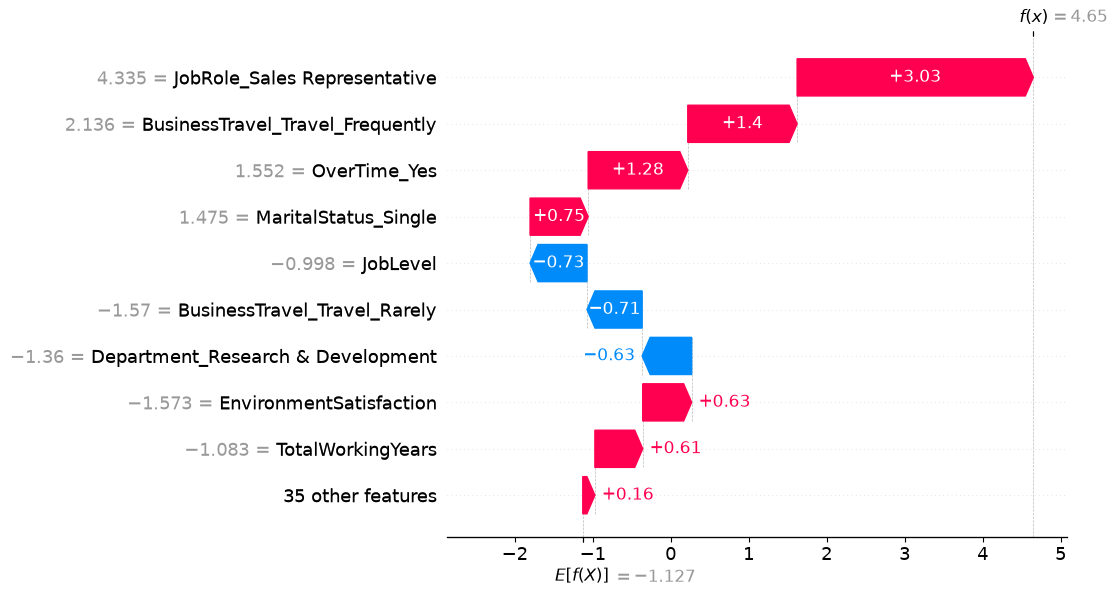

In [7]:
# Ejemplo con empleado alto riesgo de irse
probas = modelo_lr.predict_proba(X_test)[:, 1]
idx_alto = probas.argmax()

shap.plots.waterfall(shap_values[idx_alto], show=False)
plt.savefig(os.path.join(RUTA_SHAP, 'shap_waterfall_alto.png'), dpi=150, bbox_inches='tight')
plt.show()

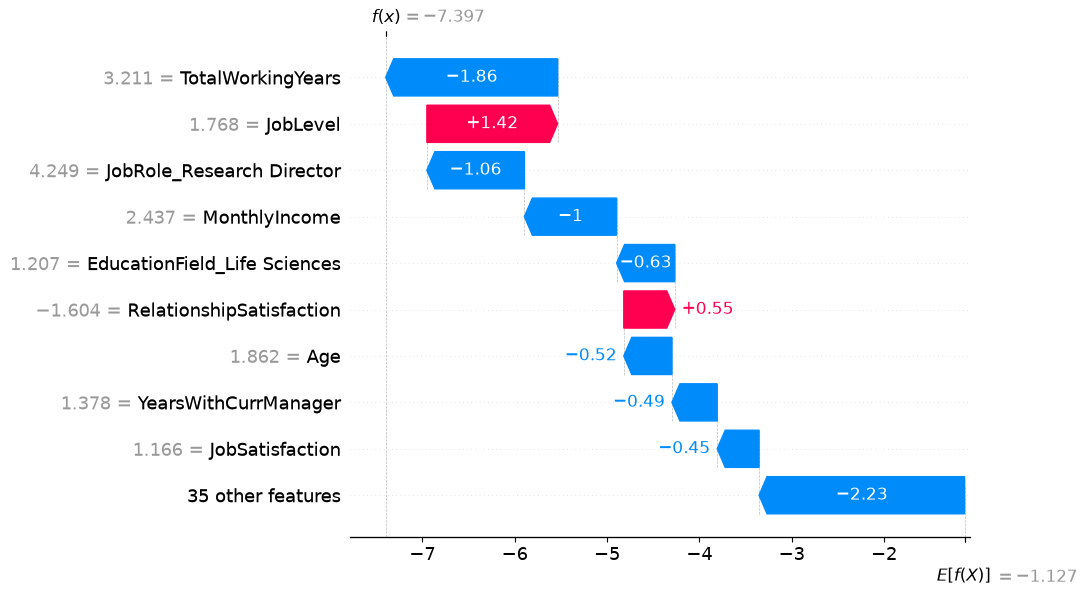

In [8]:
# Empleado con un riesgo bajo de irse
idx_bajo = probas.argmin()   

shap.plots.waterfall(shap_values[idx_bajo], show=False)
plt.savefig(os.path.join(RUTA_SHAP, 'shap_waterfall_bajo.png'), dpi=150, bbox_inches='tight')
plt.show()

Empleado 397 - riesgo de rotacion: 79.24%


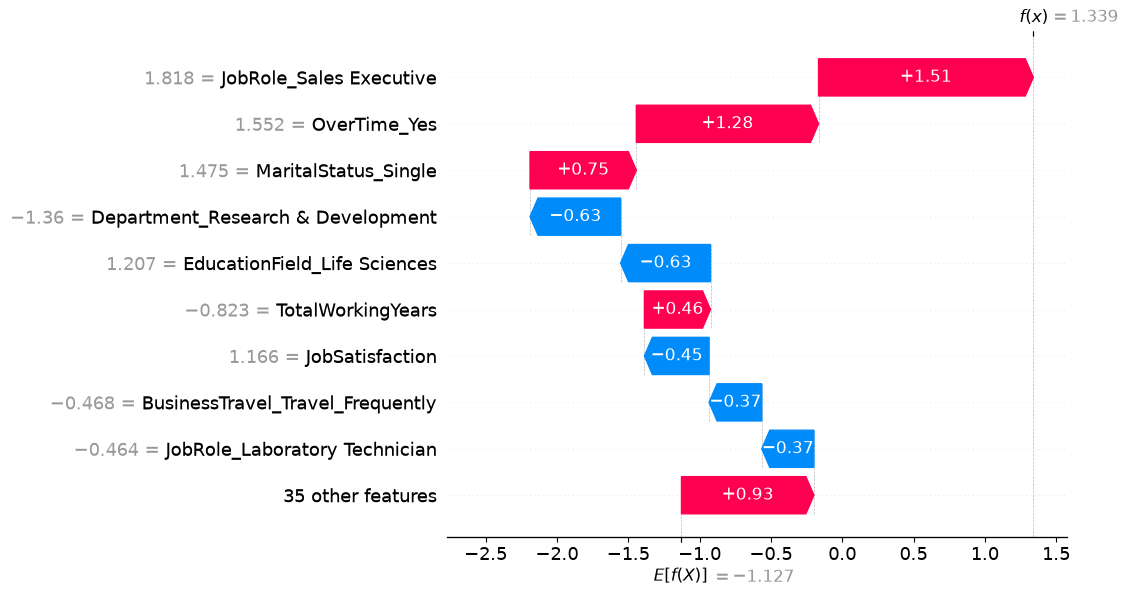

In [9]:
# Función para ver el waterfall de un empleado concreto por su ID, para cuando RRHH quiera revisar un caso especifico
def waterfall_empleado(employee_id):
    # El id del empleado no es lo mismo que su posición en el array, por lo que busco la posición primero
    posicion = X_test.index.get_loc(employee_id)

    # Sacó su probabilidad de riesgo para mostrarla
    score = modelo_lr.predict_proba(X_test)[:, 1][posicion]
    print(f"Empleado {employee_id} - riesgo de rotacion: {score:.2%}")

    # Genero el waterfall de ese empleado
    shap.plots.waterfall(shap_values[posicion], show=False)
    plt.show()

# Ejemplo de empleado
waterfall_empleado(X_test.index[0])

## LIME

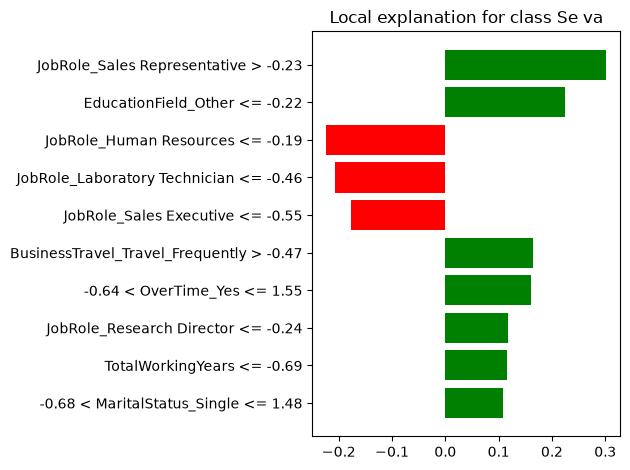

In [10]:
import lime
import lime.lime_tabular

# LIME usa los datos de entrenamiento escalados
X_train_escalado = scaler.transform(X_train)

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_escalado,
    feature_names=X_train.columns.tolist(),
    class_names=['Se queda', 'Se va'],
    mode='classification'
)

# Usamos el mismo empleado con el riesgo alto que vimos con SHAP
idx_alto = probas.argmax()   

exp = explainer_lime.explain_instance(
    X_test_escalado.iloc[idx_alto].values,
    lr_modelo.predict_proba,
    num_features=10
)

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig(os.path.join(RUTA_SHAP, 'lime_empleado_alto.png'), dpi=150, bbox_inches='tight')
plt.show()

## Interpretabilidad del modelo — Conclusiones

El modelo ganardor (Regresión Logística) es interpretable de forma nativa a través de sus coeficientes. Sobre esa base se aplicaron SHAP y LIME para 
añador una forma de comunicación visual para perfiles de RRHH que no son tan técnicos.

-SHAP: El summary plot identifica los principales impulsores de la rotación, como OverTime, YearsAtCompany, MaritalStatus_Single y el rol del empleado,
coherentes con el análisis exploratorio y con los coeficientes del modelo, lo que confirma la consistencia del pipeline. Los waterfall plots 
individuales muestran la predicción de cada empleado, identificandolos mediante el ID, mostrando qué factores elevan o reducen su riesgo y permitiendo
a RRHH una intervención accionable caso por caso.

-LIME: Con este aplicado al mismo empleado de riesgo alto, vemos que coincide con SHAP en los principales factores, reforzando la interpretación con el
uso de dos métodos independientes. LIME presenta mayor dispersión y menor estabilidad entre ejecuciones, por lo que se emplea como apoyo y no como 
método principal.

Como conclusión podemos decir que en un modelo lineal, SHAP converge con los coeficientes, no aporta información adicional, sino una mejor visual
que hace la interpretación más accesible y rápida para perfiles no técnicos. Estas dos formas de mostrar los resultados es el puente entre el modelo y 
la decisión de negocio de RRHH.

In [12]:
# Importancia global = media de contribucion por feature (equivalente a SHAP mean-abs)
import pandas as pd, os
RUTA_OUT = os.path.join(RUTA_BASE, 'outputs')

shap_local = pd.read_csv(os.path.join(RUTA_OUT, 'shap_local.csv'))          # employee_id, feature, contribucion
coef = pd.read_csv(os.path.join(RUTA_TABLES, 'coeficientes_lr.csv'))        # variable, coeficiente
coef = coef.rename(columns={'variable': 'feature'})

imp = (shap_local.groupby('feature')['contribucion']
       .apply(lambda s: s.abs().mean())
       .reset_index(name='importancia_shap'))

imp = imp.merge(coef, on='feature', how='left')
imp['signo'] = imp['coeficiente'].apply(lambda c: 'Sube riesgo' if c > 0 else 'Baja riesgo')

imp = imp.sort_values('importancia_shap', ascending=False)
imp.to_csv(os.path.join(RUTA_OUT, 'importancia_global_shap.csv'), index=False)
imp.head(10)

,feature,importancia_shap,coeficiente,signo
32,OverTime_Yes,0.689400,0.784311,Sube riesgo
24,JobRole_Sales Executive,0.633746,0.791995,Sube riesgo
17,JobLevel,0.631923,0.775677,Sube riesgo
19,JobRole_Laboratory Technician,0.606070,0.798219,Sube riesgo
1,BusinessTravel_Travel_Frequently,0.555241,0.680359,Sube riesgo
8,EducationField_Life Sciences,0.531601,-0.537521,Baja riesgo
28,MaritalStatus_Single,0.487215,0.517301,Sube riesgo
37,TotalWorkingYears,0.468334,-0.576415,Baja riesgo
42,YearsSinceLastPromotion,0.441426,0.597166,Sube riesgo
4,Department_Research & Development,0.430838,0.455943,Sube riesgo
